## Building ChatBot with Multiple Tools using LangGraph

- Aim: Create a chatbot with tool capabilities from arxiv, wikipedia search and some funtions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(
    top_k_results=2,
    doc_content_chars_max=500
)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki= WikipediaAPIWrapper(
    top_k_results=1,
    doc_content_chars_max=500
)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

#### Tavily: Real-time search, extraction, research, and web crawling through a single, secure API.

In [8]:
# Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\mani2\AppData\Local\Temp\ipykernel_23956\3336424662.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [9]:
tavily.invoke("Provide me the recent AI news for 5th April 2026")

[{'title': 'AI News & Trends April 2026: Complete Monthly Digest - AIFOD',
  'url': 'https://af.net/realtime/ai-news-trends-april-2026-complete-monthly-digest/',
  'content': "Tesla has launched mass production of its Optimus V3 humanoid robots, aiming to produce 10,000 unit…特斯拉正式启动Optimus V3人形机器人的大规模生产，计划到2026年生产1万台。每台售价低于2万美元，这些机…Tesla a lancé la production en série de ses robots humanoïdes Optimus V3, visant à produire 10 000 …أعلنت تسلا عن بدء الإنتاج الضخم لروبوتاتها البشرية Optimus V3، مستهدفة إنتاج 10,000 وحدة بحلول عام …\n\n#### Microsoft Drives Copilot Adoption Amid Investor Concerns Over AI Monetization微软推动Copilot采用，投资者担忧AI盈利能力Microsoft Accélère l'Adoption de Copilot Face aux Inquiétudes des Investisseurs…مايكروسوفت تدفع بتبني Copilot وسط مخاوف المستثمرين بشأن تحقيق الأرباح من الذكاء… [...] Tesla has launched mass production of its Optimus V3 humanoid robots, aiming to produce 10,000 unit…特斯拉正式启动Optimus V3人形机器人的大规模生产，计划到2026年生产1万台。每台售价低于2万美元，这些机…Tesla a lancé la production en

In [10]:
# Combine all the tools in the list
tools = [arxiv, wiki, tavily]

In [11]:
# Initialize my LLM model
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI

# llm=ChatGroq(model="qwen-qwq-32b")  # model decommissioned
llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools=llm.bind_tools(tools)

c:\Users\mani2\Documents\RAG-Mastery\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 216, 'total_tokens': 236, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DRciJeb5Lbdl4tW3ipydOQrb8TLF3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d629e-6abb-75f1-877e-a1ed7603932a-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': 'call_hXvAcFKUZ0SjbCOFHdLd5TLE', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 216, 'output_tokens': 20, 'total_tokens': 236, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea

In [13]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'call_ynUeyXjTo6COCFiNd3ipcgfY',
  'type': 'tool_call'}]

In [14]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

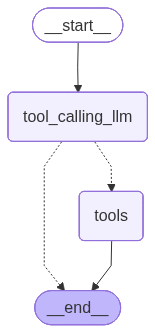

In [15]:
# Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_RGipCWErjZRFa8mU0x0wGhi1)
 Call ID: call_RGipCWErjZRFa8mU0x0wGhi1
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [17]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for 5th April 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for 5th April 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_pHVM0cHrk35sFSs4CxQpH4Bo)
 Call ID: call_pHVM0cHrk35sFSs4CxQpH4Bo
  Args:
    query: AI news April 5 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "New AI Model Releases News | April, 2026 (STARTUP EDITION)", "url": "https://blog.mean.ceo/new-ai-model-releases-news-april-2026", "content": "## AI (artificial intelligence) news, April 2026\n\nThe biggest business news in AI heading into April: OpenAI surpassed $25 billion in annualized revenue and is reportedly taking early steps toward a public listing, potentially as soon as late 2026, while Anthropic is approaching $19 billion in annualized revenue. These numbers signal that enterprise AI a

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_JP3GLZQBMlu6C47jkTIfYtFE)
 Call ID: call_JP3GLZQBMlu6C47jkTIfYtFE
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches 
